# 회귀분석_최적회귀_정규화_tree회귀

## 보스턴집값데이터 회귀분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [3]:
data=pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/01%EB%B3%B4%EC%8A%A4%ED%84%B4%EC%A7%91%EA%B0%92%EB%8D%B0%EC%9D%B4%ED%84%B0.csv")

In [4]:
data.head()

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
len(data)

506

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   범죄율           506 non-null    float64
 1   25,000평방피트초과  506 non-null    float64
 2   비소매상업지역비율     506 non-null    float64
 3   찰스강경계         506 non-null    int64  
 4   농축 일산화질소      506 non-null    float64
 5   가구당평균방수       506 non-null    float64
 6   1940년이전건축비율   506 non-null    float64
 7   직업센터접근성       506 non-null    float64
 8   도로접근성         506 non-null    int64  
 9   재산세율          506 non-null    float64
 10  학생/교사비율       506 non-null    float64
 11  흑인비율          506 non-null    float64
 12  하위계층비율        506 non-null    float64
 13  주택가격          506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
data.isna().sum()

범죄율             0
25,000평방피트초과    0
비소매상업지역비율       0
찰스강경계           0
농축 일산화질소        0
가구당평균방수         0
1940년이전건축비율     0
직업센터접근성         0
도로접근성           0
재산세율            0
학생/교사비율         0
흑인비율            0
하위계층비율          0
주택가격            0
dtype: int64

In [8]:
data['도로접근성']

0      1
1      2
2      2
3      3
4      3
      ..
501    1
502    1
503    1
504    1
505    1
Name: 도로접근성, Length: 506, dtype: int64

In [9]:
data.corr(method='spearman')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
범죄율,1.000000,-0.571660,0.735524,0.041537,0.821465,-0.309116,0.704140,-0.744986,0.727807,0.729045,0.465283,-0.360555,0.634760,-0.558891
"25,000평방피트초과",-0.571660,1.000000,-0.642811,-0.041937,-0.634828,0.361074,-0.544423,0.614627,-0.278767,-0.371394,-0.448475,0.163135,-0.490074,0.438179
비소매상업지역비율,0.735524,-0.642811,1.000000,0.089841,0.791189,-0.415301,0.679487,-0.757080,0.455507,0.664361,0.433710,-0.285840,0.638747,-0.578255
찰스강경계,0.041537,-0.041937,0.089841,1.000000,0.068426,0.058813,0.067792,-0.080248,0.024579,-0.044486,-0.136065,-0.039810,-0.050575,0.140612
농축 일산화질소,0.821465,-0.634828,0.791189,0.068426,1.000000,-0.310344,0.795153,-0.880015,0.586429,0.649527,0.391309,-0.296662,0.636828,-0.562609
가구당평균방수,-0.309116,0.361074,-0.415301,0.058813,-0.310344,1.000000,-0.278082,0.263168,-0.107492,-0.271898,-0.312923,0.053660,-0.640832,0.633576
1940년이전건축비율,0.704140,-0.544423,0.679487,0.067792,0.795153,-0.278082,1.000000,-0.801610,0.417983,0.526366,0.355384,-0.228022,0.657071,-0.547562
직업센터접근성,-0.744986,0.614627,-0.757080,-0.080248,-0.880015,0.263168,-0.801610,1.000000,-0.495806,-0.574336,-0.322041,0.249595,-0.564262,0.445857
도로접근성,0.727807,-0.278767,0.455507,0.024579,0.586429,-0.107492,0.417983,-0.495806,1.000000,0.704876,0.318330,-0.282533,0.394322,-0.346776
재산세율,0.729045,-0.371394,0.664361,-0.044486,0.649527,-0.271898,0.526366,-0.574336,0.704876,1.000000,0.453345,-0.329843,0.534423,-0.562411


<Axes: >

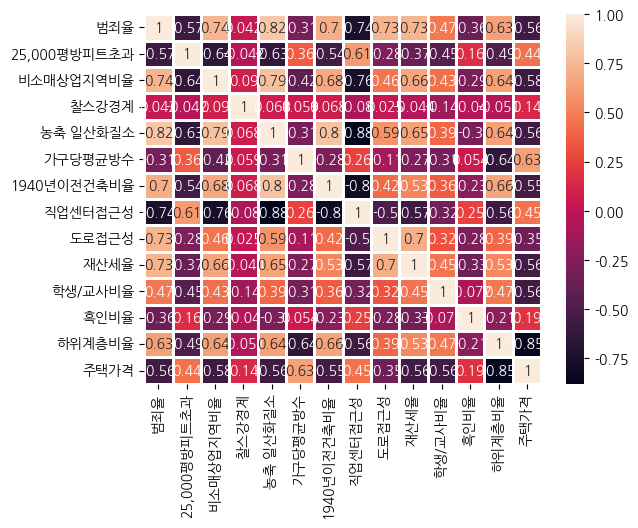

In [10]:
sns.heatmap(data.corr(method='spearman'), annot=True, linewidth=1)

In [7]:
data.columns

Index(['범죄율', '25,000평방피트초과', '비소매상업지역비율', '찰스강경계', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율',
       '주택가격'],
      dtype='object')

In [10]:
cols=data.columns[:-1]

========================= 범죄율 =========================


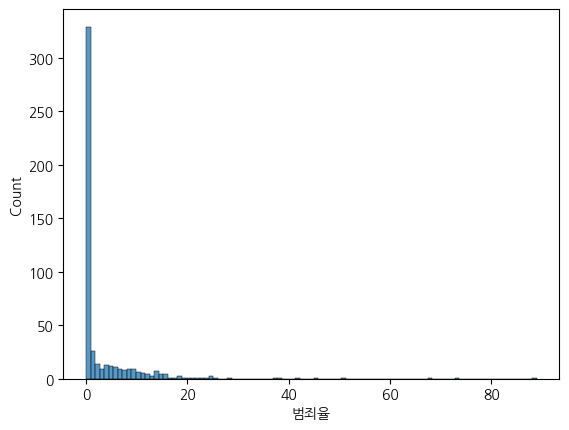


========================= 25,000평방피트초과 =========================


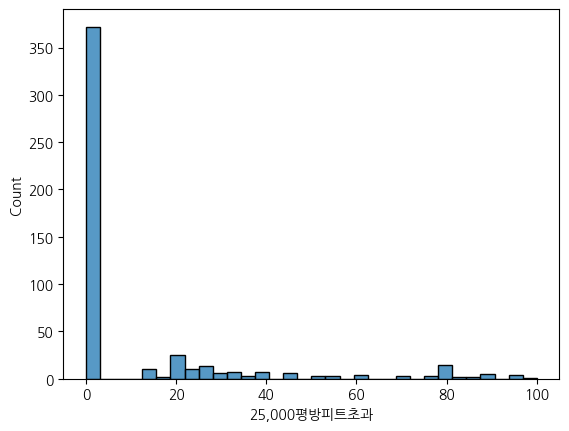


========================= 비소매상업지역비율 =========================


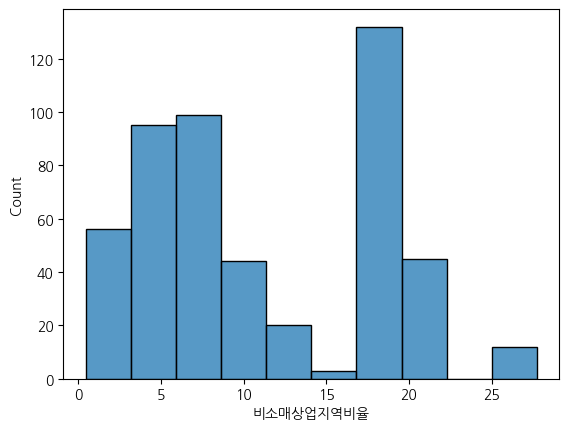


========================= 찰스강경계 =========================


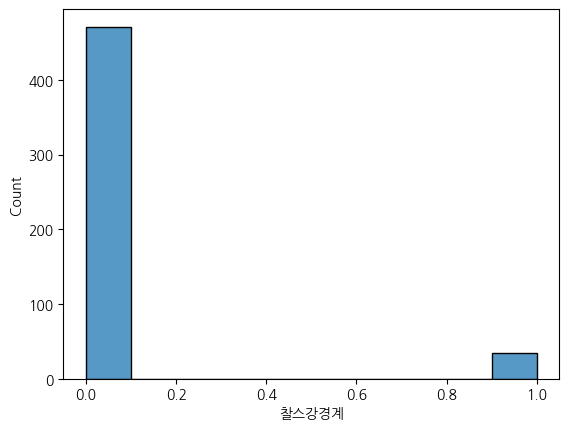


========================= 농축 일산화질소 =========================


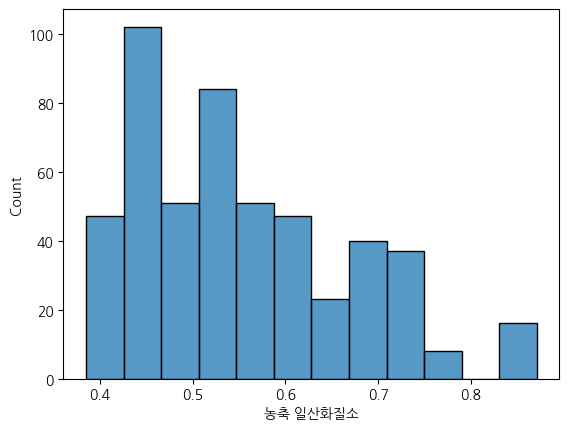


========================= 가구당평균방수 =========================


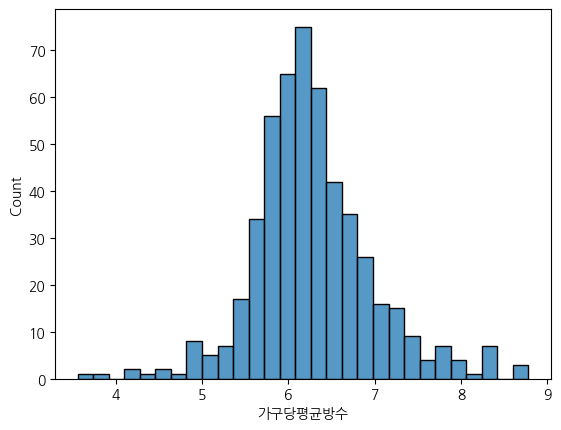


========================= 1940년이전건축비율 =========================


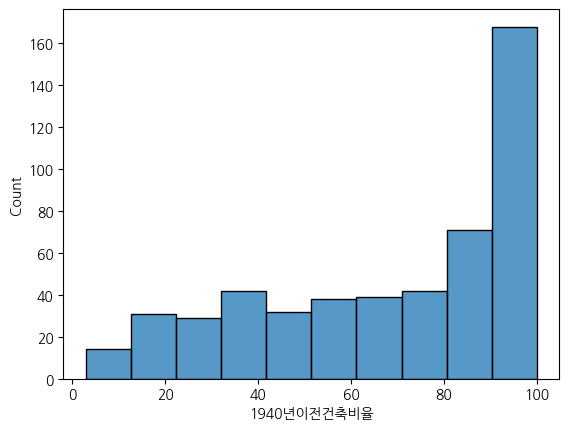


========================= 직업센터접근성 =========================


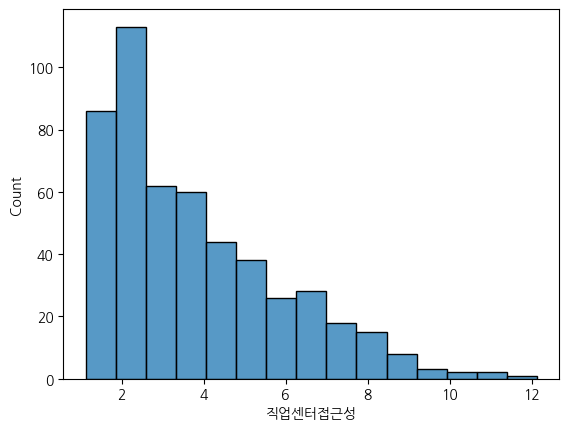


========================= 도로접근성 =========================


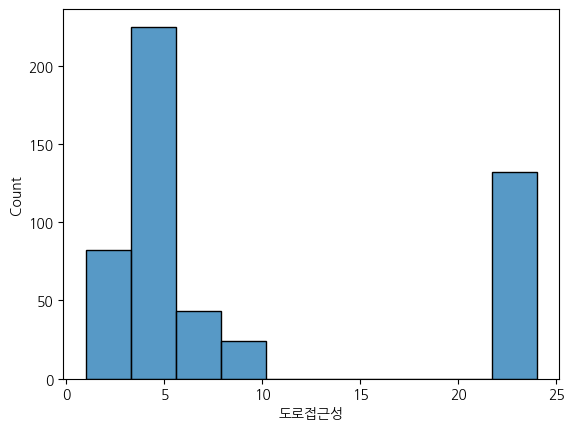


========================= 재산세율 =========================


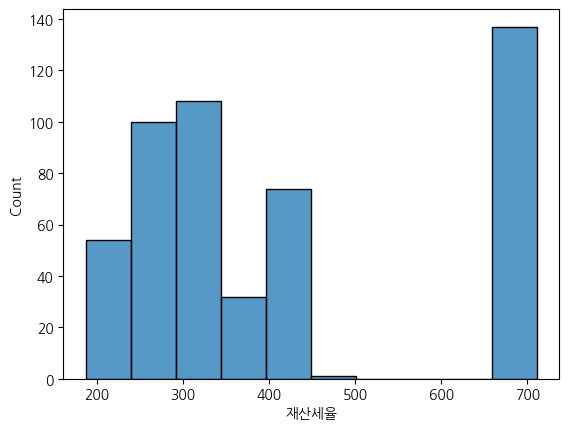


========================= 학생/교사비율 =========================


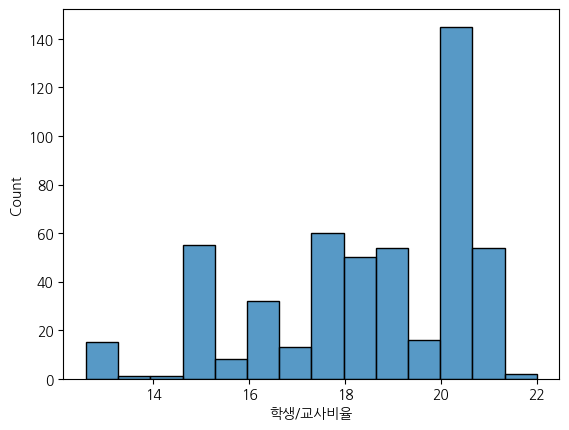


========================= 흑인비율 =========================


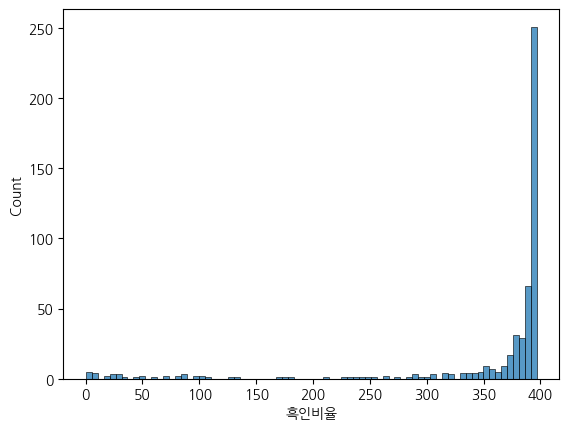


========================= 하위계층비율 =========================


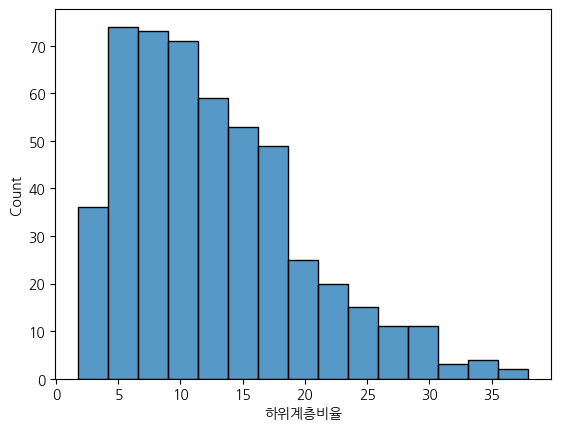

In [11]:
for col in cols:
    print("="*25, col, "="*25)
    sns.histplot(data[col])
    plt.show()
    print()

In [13]:
data['25,000평방피트초과'].value_counts()

25,000평방피트초과
0.0      372
20.0      21
80.0      15
22.0      10
25.0      10
12.5      10
40.0       7
30.0       6
45.0       6
90.0       5
33.0       4
21.0       4
95.0       4
60.0       4
75.0       3
28.0       3
52.5       3
55.0       3
34.0       3
70.0       3
35.0       3
85.0       2
82.5       2
17.5       1
18.0       1
100.0      1
Name: count, dtype: int64

In [14]:
# 카테고리 변수
data['찰스강경계'].value_counts()

찰스강경계
0    471
1     35
Name: count, dtype: int64

In [15]:
data['도로접근성'].value_counts()

도로접근성
24    132
5     115
4     110
3      38
6      26
8      24
2      24
1      20
7      17
Name: count, dtype: int64

<Axes: >

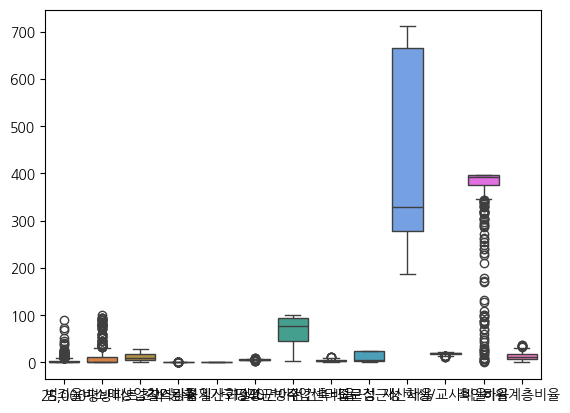

In [18]:
sns.boxplot(data.drop("주택가격", axis=1))

# 데이터 홀드아웃, 스케일링, 분석

In [25]:
X=data.drop('주택가격', axis=1)
y=data['주택가격']

In [27]:
# 홀드아웃
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
encoder=OneHotEncoder(drop='first', sparse_output=False)
X_train_cat=encoder.fit_transform(X_train[['찰스강경계']])
X_test_cat=encoder.transform(X_test[['찰스강경계']])

In [34]:
scaler=StandardScaler()
X_train_num = scaler.fit_transform(X_train[['범죄율', '25,000평방피트초과', '비소매상업지역비율', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율']])
X_test_num = scaler.transform(X_test[['범죄율', '25,000평방피트초과', '비소매상업지역비율', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율']])

In [61]:
X_train_num_df = pd.DataFrame(X_train_num, columns=['범죄율', '25,000평방피트초과', '비소매상업지역비율', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율'], index=X_train.index )
X_test_num_df = pd.DataFrame(X_test_num, columns=['범죄율', '25,000평방피트초과', '비소매상업지역비율', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율'], index=X_test.index)

# 범주형 변수
X_train_cat_df = pd.DataFrame(X_train_cat, columns=['찰스강경계'], index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=['찰스강경계'], index=X_test.index)

# 6. DataFrame으로 결합
X_train_final = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

In [52]:
X_test_final

,범죄율,"25,000평방피트초과",비소매상업지역비율,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
173,-0.396809,-0.500320,-1.007111,-0.395412,0.141282,0.555916,-0.545853,-0.507797,-0.650926,-0.771951,0.428872,-0.481210,0.0
274,-0.400796,1.229499,-0.664391,-0.931315,0.623942,-1.275254,0.126565,-0.624360,-0.903989,-0.322703,0.444180,-1.257094,1.0
491,-0.395234,-0.500320,2.433163,0.446720,-0.469805,1.081663,-0.911447,-0.624360,1.849573,0.800418,0.369934,0.790338,0.0
72,-0.396825,-0.500320,-0.025421,-1.220532,-0.354079,-2.172957,0.694876,-0.624360,-0.596698,0.396095,0.378682,-0.976875,0.0
452,0.167084,-0.500320,1.033237,1.331384,-0.026661,0.831307,-0.676503,1.706891,1.578434,0.845343,0.315043,0.677687,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,1.715000,-0.500320,1.033237,0.344643,-2.382098,1.124581,-1.059057,1.706891,1.578434,0.845343,-3.580942,3.085604,0.0
436,1.219719,-0.500320,1.033237,1.561057,0.204790,0.884955,-0.848260,1.706891,1.578434,0.845343,-3.595156,0.787522,0.0
411,1.177967,-0.500320,1.033237,0.344643,0.481403,1.124581,-1.071460,1.706891,1.578434,0.845343,-3.512491,1.233902,0.0
86,-0.401311,-0.500320,-0.943214,-0.914302,-0.424644,-0.838921,0.290806,-0.740922,-0.946166,0.081621,0.434230,0.056698,0.0


In [53]:
X_train_final

,범죄율,"25,000평방피트초과",비소매상업지역비율,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
477,1.287702,-0.500320,1.033237,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505,0.0
15,-0.336384,-0.500320,-0.413160,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474,0.0
332,-0.403253,1.013271,-0.715218,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595,0.0
423,0.388230,-0.500320,1.033237,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387,0.0
19,-0.325282,-0.500320,-0.413160,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.387850,-0.500320,-0.352167,-0.310348,-0.677264,0.834884,-0.750355,-0.507797,-0.120700,1.159817,0.430731,0.873419,0.0
270,-0.373414,0.364589,-0.584520,-0.786706,-0.649038,-0.946216,0.291651,-0.740922,-1.090773,0.126546,0.353970,0.076412,0.0
348,-0.405470,2.959318,-1.303361,-1.033391,0.450354,-1.389703,2.130899,-0.624360,-0.747331,-0.592251,0.379010,-0.910692,0.0
435,0.851897,-0.500320,1.033237,1.561057,0.441886,0.931450,-0.790898,1.706891,1.578434,0.845343,-2.694586,1.522570,0.0


In [54]:

X_test_final

,범죄율,"25,000평방피트초과",비소매상업지역비율,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
173,-0.396809,-0.500320,-1.007111,-0.395412,0.141282,0.555916,-0.545853,-0.507797,-0.650926,-0.771951,0.428872,-0.481210,0.0
274,-0.400796,1.229499,-0.664391,-0.931315,0.623942,-1.275254,0.126565,-0.624360,-0.903989,-0.322703,0.444180,-1.257094,1.0
491,-0.395234,-0.500320,2.433163,0.446720,-0.469805,1.081663,-0.911447,-0.624360,1.849573,0.800418,0.369934,0.790338,0.0
72,-0.396825,-0.500320,-0.025421,-1.220532,-0.354079,-2.172957,0.694876,-0.624360,-0.596698,0.396095,0.378682,-0.976875,0.0
452,0.167084,-0.500320,1.033237,1.331384,-0.026661,0.831307,-0.676503,1.706891,1.578434,0.845343,0.315043,0.677687,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,1.715000,-0.500320,1.033237,0.344643,-2.382098,1.124581,-1.059057,1.706891,1.578434,0.845343,-3.580942,3.085604,0.0
436,1.219719,-0.500320,1.033237,1.561057,0.204790,0.884955,-0.848260,1.706891,1.578434,0.845343,-3.595156,0.787522,0.0
411,1.177967,-0.500320,1.033237,0.344643,0.481403,1.124581,-1.071460,1.706891,1.578434,0.845343,-3.512491,1.233902,0.0
86,-0.401311,-0.500320,-0.943214,-0.914302,-0.424644,-0.838921,0.290806,-0.740922,-0.946166,0.081621,0.434230,0.056698,0.0


# 다중선형회귀분석

In [62]:
import statsmodels.api as sm

In [63]:
X_train_final_const=sm.add_constant(X_train_final)
X_test_final_const=sm.add_constant(X_test_final)

In [64]:
X_train_final_const.head()

,const,범죄율,"25,000평방피트초과",비소매상업지역비율,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
477,1.0,1.287702,-0.500320,1.033237,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505,0.0
15,1.0,-0.336384,-0.500320,-0.413160,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474,0.0
332,1.0,-0.403253,1.013271,-0.715218,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595,0.0
423,1.0,0.388230,-0.500320,1.033237,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387,0.0
19,1.0,-0.325282,-0.500320,-0.413160,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787,0.0


In [65]:
lr=sm.OLS(y_train, X_train_final_const).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     90.43
Date:                Thu, 08 May 2025   Prob (F-statistic):          6.21e-109
Time:                        13:36:20   Log-Likelihood:                -1194.3
No. Observations:                 404   AIC:                             2417.
Df Residuals:                     390   BIC:                             2473.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           22.5967      0.245     92.099   

In [70]:
X_train_final

,범죄율,"25,000평방피트초과",비소매상업지역비율,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
477,1.287702,-0.500320,1.033237,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505,0.0
15,-0.336384,-0.500320,-0.413160,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474,0.0
332,-0.403253,1.013271,-0.715218,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595,0.0
423,0.388230,-0.500320,1.033237,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387,0.0
19,-0.325282,-0.500320,-0.413160,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.387850,-0.500320,-0.352167,-0.310348,-0.677264,0.834884,-0.750355,-0.507797,-0.120700,1.159817,0.430731,0.873419,0.0
270,-0.373414,0.364589,-0.584520,-0.786706,-0.649038,-0.946216,0.291651,-0.740922,-1.090773,0.126546,0.353970,0.076412,0.0
348,-0.405470,2.959318,-1.303361,-1.033391,0.450354,-1.389703,2.130899,-0.624360,-0.747331,-0.592251,0.379010,-0.910692,0.0
435,0.851897,-0.500320,1.033237,1.561057,0.441886,0.931450,-0.790898,1.706891,1.578434,0.845343,-2.694586,1.522570,0.0


In [72]:
X_train_final2=X_train_final.drop(['25,000평방피트초과','비소매상업지역비율','1940년이전건축비율'], axis=1)
X_test_final2=X_test_final.drop(['25,000평방피트초과','비소매상업지역비율','1940년이전건축비율'], axis=1)

In [73]:
X_train_final2

,범죄율,농축 일산화질소,가구당평균방수,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
477,1.287702,0.489252,-1.428069,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505,0.0
15,-0.336384,-0.157233,-0.680087,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474,0.0
332,-0.403253,-1.008723,-0.402063,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595,0.0
423,0.388230,0.489252,-0.300450,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387,0.0
19,-0.325282,-0.157233,-0.831094,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787,0.0
...,...,...,...,...,...,...,...,...,...,...
106,-0.387850,-0.310348,-0.677264,-0.750355,-0.507797,-0.120700,1.159817,0.430731,0.873419,0.0
270,-0.373414,-0.786706,-0.649038,0.291651,-0.740922,-1.090773,0.126546,0.353970,0.076412,0.0
348,-0.405470,-1.033391,0.450354,2.130899,-0.624360,-0.747331,-0.592251,0.379010,-0.910692,0.0
435,0.851897,1.561057,0.441886,-0.790898,1.706891,1.578434,0.845343,-2.694586,1.522570,0.0


In [74]:
X_test_final2

,범죄율,농축 일산화질소,가구당평균방수,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
173,-0.396809,-0.395412,0.141282,-0.545853,-0.507797,-0.650926,-0.771951,0.428872,-0.481210,0.0
274,-0.400796,-0.931315,0.623942,0.126565,-0.624360,-0.903989,-0.322703,0.444180,-1.257094,1.0
491,-0.395234,0.446720,-0.469805,-0.911447,-0.624360,1.849573,0.800418,0.369934,0.790338,0.0
72,-0.396825,-1.220532,-0.354079,0.694876,-0.624360,-0.596698,0.396095,0.378682,-0.976875,0.0
452,0.167084,1.331384,-0.026661,-0.676503,1.706891,1.578434,0.845343,0.315043,0.677687,0.0
...,...,...,...,...,...,...,...,...,...,...
412,1.715000,0.344643,-2.382098,-1.059057,1.706891,1.578434,0.845343,-3.580942,3.085604,0.0
436,1.219719,1.561057,0.204790,-0.848260,1.706891,1.578434,0.845343,-3.595156,0.787522,0.0
411,1.177967,0.344643,0.481403,-1.071460,1.706891,1.578434,0.845343,-3.512491,1.233902,0.0
86,-0.401311,-0.914302,-0.424644,0.290806,-0.740922,-0.946166,0.081621,0.434230,0.056698,0.0


In [75]:
X_train_final2_const=sm.add_constant(X_train_final2)
X_test_final2_const=sm.add_constant(X_test_final2)

In [76]:
X_train_final2_const.head()

,const,범죄율,농축 일산화질소,가구당평균방수,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,찰스강경계
477,1.0,1.287702,0.489252,-1.428069,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505,0.0
15,1.0,-0.336384,-0.157233,-0.680087,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474,0.0
332,1.0,-0.403253,-1.008723,-0.402063,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595,0.0
423,1.0,0.388230,0.489252,-0.300450,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387,0.0
19,1.0,-0.325282,-0.157233,-0.831094,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787,0.0


In [78]:
lr=sm.OLS(y_train, X_train_final2_const).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     116.8
Date:                Thu, 08 May 2025   Prob (F-statistic):          3.85e-111
Time:                        13:44:48   Log-Likelihood:                -1196.4
No. Observations:                 404   AIC:                             2415.
Df Residuals:                     393   BIC:                             2459.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5901      0.246     91.995      0.0

# 회귀분석의 평가지표

In [79]:
from sklearn.metrics import mean_squared_error

In [82]:
pred=lr.predict(X_test_final2_const)

In [83]:
print("mean_squared_error: ", mean_squared_error(y_test, pred))
print("root_mean_squared_error: ", np.sqrt(mean_squared_error(y_test, pred)))

mean_squared_error:  25.50021259817648
root_mean_squared_error:  5.049773519493372


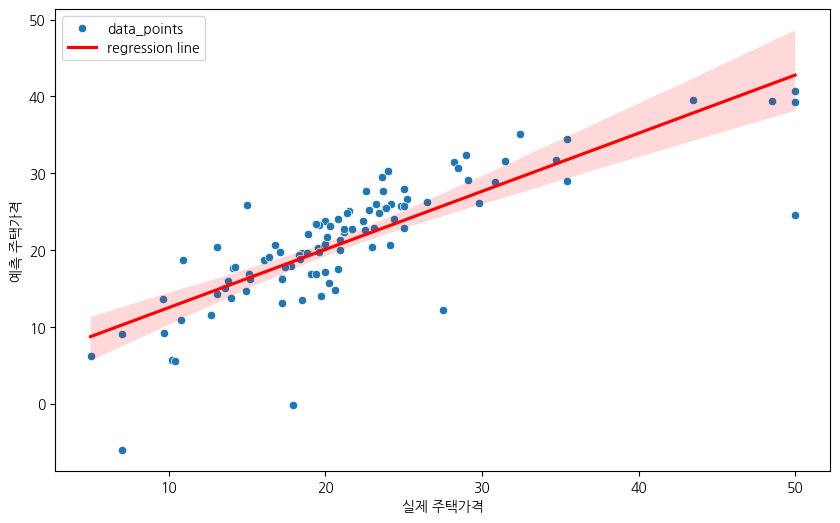

In [84]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=pred, label='data_points')
sns.regplot(x=y_test, y=pred, scatter=False, label="regression line", color='red')
plt.xlabel("실제 주택가격")
plt.ylabel("예측 주택가격")
plt.legend()
plt.show()

# 정규화를 통한 선형회귀 변수 선택법
## 1) Lasso회귀(L1규제)
* 가중치의 절대값의 합을 최소화
* 일부 가중치를 0으로 만들어서 변수를 무력화
* 변수를 선택하는 효과
* 불필요한 변수 제거

## 2) Ridge 회귀(L2규제)
* 가중치의 제곱합을 최소화
* 계수를 0에 가깝게 만들지만 제거는 하지 않음
* 다중공선성 해결에 효과적

## 3) Elastic Net(혼합 규제, L1+L2)
* L1규제와 L2규제를 결합한 모델
* Lasso와 Ridge의 장점을 모두 활용
* 변수 간 상관관계가 높을 때 효과적

# 정규화 회귀를 사용하는 이유: 과적합 방지, 범용성 향상

# 라쏘(Lasso, L1제약, 절대값, 변수제외)

In [86]:
from sklearn.linear_model import Lasso

In [87]:
lasso= Lasso(alpha=1.0)
lasso.fit(rs_X_train, y_train)
pred=lasso.predict(rs_X_test)
lasso_result=pd.DataFrame(lasso.coef_, index=lasso.feature_names_in_)
display(lasso_result)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))


NameError: name 'rs_X_train' is not defined

alpha 값을 변경하면서 비교

In [ ]:
for i in range(1, 10):
    lasso= Lasso(alpha=i)
    lasso.fit(rs_X_train, y_train)
    pred=lasso.predict(rs_X_test)
    lasso_result=pd.DataFrame(lasso.coef_, index=lasso.feature_names_in_)
    print("="*20, f"alpha={i})
    display(lasso_result)
    print("MAE: ", mean_absolute_error(y_test,pred))
    print("MSE: ", mean_squared_error(y_test,pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
    print("R2: ", r2_score(y_test, pred))


# 릿지(Ridge, L2제약, 제곱합, 변수를 0에 가깝게 만들어 무력화)

In [88]:
from sklearn.linear_model import Ridge

In [ ]:
ridge=Ridge(alpha=1.0)
ridge.fit(rs_X_train, y_train)
pred=ridge.predict(rs_X_test)
ridge_result=pd.DataFrame(ridge.coef_, index=ridge.feature_names_in_)
display(ridge_result)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

In [ ]:
ridge=Ridge(alpha=30)
ridge.fit(rs_X_train, y_train)
pred=ridge.predict(rs_X_test)
ridge_result=pd.DataFrame(ridge.coef_, index=ridge.feature_names_in_)
display(ridge_result)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

# Elastic Net(Lasso와 Ridge를 동시에 사용, L1+L2)

In [89]:
from sklearn.linear_model import ElasticNet

In [ ]:
el_net=ElasticNet(alpha=1, l1_ratio=0.3)
el_net.fit(rs_X_train, y_train)
pred=el_net.predict(rs_X_test)
el_net_result=pd.DataFrame(el_net.coef_, index=el_net.feature_names_in_)
display(el_net_result)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

# LassoCV, RidgeCV, ElasticnetCV

In [90]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

In [ ]:
alphas=np.

In [ ]:
lassoCV= LassoCV(alphas=alphas, cv=5, n_jobs=4, random_state=42)
lassoCV.fit(rs_X_train, y_train)
print(lassoCV.alpha_)


In [ ]:
lasso=Lasso(alpha=0.0001)
lasso.fit(rs_X_train, y_train)
pred=lasso.predict(rs_X_test)
lasso_result=pd.DataFrame(lasso.coef_, index=lasso.feature_names_in_)
display(lasso_result)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

In [ ]:
RidgeCV= RidgeCV(alphas=alphas, cv=5, n_jobs=4, random_state=42)
lassoCV.fit(rs_X_train, y_train)
print(lassoCV.alpha_)

In [ ]:
rations=np.linspace(0.1, 1, 10)
rations

In [ ]:
el_netCV=ElasticNetCV(alphas=alphas, cv=5, n_jobs=4, random_state=42)
el_netCV.fit(rs_X_train, y_train)
print(el_netCV.alpha_, el_netCV.L1_ratio_)

In [ ]:
lasso=Lasso(alpha=0.0001)
lasso.fit(rs_X_train, y_train)
pred=lasso.predict(rs_X_test)
lasso_result=pd.DataFrame(lasso.coef_, index=lasso.feature_names_in_)
display(lasso_result)
print("MAE: ", mean_absolute_error(y_test,pred))
print("MSE: ", mean_squared_error(y_test,pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
print("R2: ", r2_score(y_test, pred))

# Tree계열 회귀 사용하기
* decisionTree, Randomforest, xgboost, lightgbm은 모두 회귀분석도 가능

In [91]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
for i in range(1, 10):
    dtr=DecisionTreeRegressor(max_depth=3, random_state=42)
    dtr.fit(rs_X_train, y_train)
    pred=dtr.predict(rs_X_test)
    dtr_result=pd.DataFrame(dtr.feature_importances_, index=lasso.feature_names_in_)
    display(lasso_result)
    print("MAE: ", mean_absolute_error(y_test,pred))
    print("MSE: ", mean_squared_error(y_test,pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_test,pred)))
    print("R2: ", r2_score(y_test, pred))

In [92]:
from sklearn.tree import plot_tree

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dtr, max_depth=3, feature_names=dtr.feature_names_in_, fonsize=15)

In [ ]:
def personal_info6(idx, address='비공개', *args, **kwargs):
    print(f"idx:{idx}")
    print(f"address: {address})
    print(f"*args:{args}")
    print(f"**kwargs:{kwargs}")

In [ ]:
personal_info6(1,"서울", 30, 40, 5)

In [ ]:
rf